# Cross-channel distance-sampling figure

The figure uses matched WT split violins for a manuscript figure. Each panel compares WT vanilla and WT targeted-masked predictions using the final channel-specific QC subset. The manuscript row order is Kv2.1, NaV1.5, and CaV1.2. Experimental markers use the same PDB-specific colors and shapes as the channel notebooks and are enlarged for readability.

The recommended main figure contains the voltage-sensor and intracellular-gate columns. These are the regions that most directly test whether masking changes access to alternative channel geometries. The selectivity-filter column is exported as a matched structural control and is better suited to a supplementary or extended-data figure. The original canvas dimensions are retained. Moderate GridSpec spacing makes the data panels larger than in the original layout while preserving clear separation between rotated residue labels, row titles, and legends. Title, axis-label, tick-label, and marker sizes remain fixed. The setup cell reloads the plotting module so layout edits are applied without requiring a kernel restart. Nav1.5 panel titles are shortened to WT; the underlying comparison still uses the matched masked-v2 table and remains identified in the setup output. In the experimental-reference legend, Kv2.1 occupies the first two columns, column three is a visual spacer, Nav1.5 occupies column four, and Cav1.2 occupies column five.

In [25]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'shared').is_dir())
sys.path.insert(0, str(repo_root))

import importlib
import shared.cross_channel_distance_figure as cross_channel_distance_figure
importlib.reload(cross_channel_distance_figure)

load_paper_data = cross_channel_distance_figure.load_paper_data
make_grid = cross_channel_distance_figure.make_grid
make_individual_panels = cross_channel_distance_figure.make_individual_panels
paper_configs = cross_channel_distance_figure.paper_configs

configs = paper_configs(repo_root)
data = load_paper_data(configs)
figures = repo_root / 'docs' / 'figures' / 'cross_channel_distance_sampling'
figures.mkdir(parents=True, exist_ok=True)

for channel, config in configs.items():
    protocol_note = f" | {config['protocol_note']}" if config.get('protocol_note') else ""
    print(f"{channel}: {config['condition']}{protocol_note} | vanilla={len(data[channel]['vanilla'])} | masked={len(data[channel]['masked'])}")

Kv2.1: WT | vanilla=4562 | masked=3658
Nav1.5: WT | targeted mask v2 | vanilla=5000 | masked=4999
Cav1.2: WT | vanilla=5000 | masked=4996


## Recommended main figure

Only WT ensembles are shown at this stage. Rows follow the manuscript order: Kv2.1, NaV1.5, and CaV1.2. Columns move from the intracellular activation gate to the selectivity filter and then the voltage sensors, so pore opening, pore integrity, and voltage-sensor variability can be read from left to right. All panels use the final channel-specific QC subsets and identical dimensions.

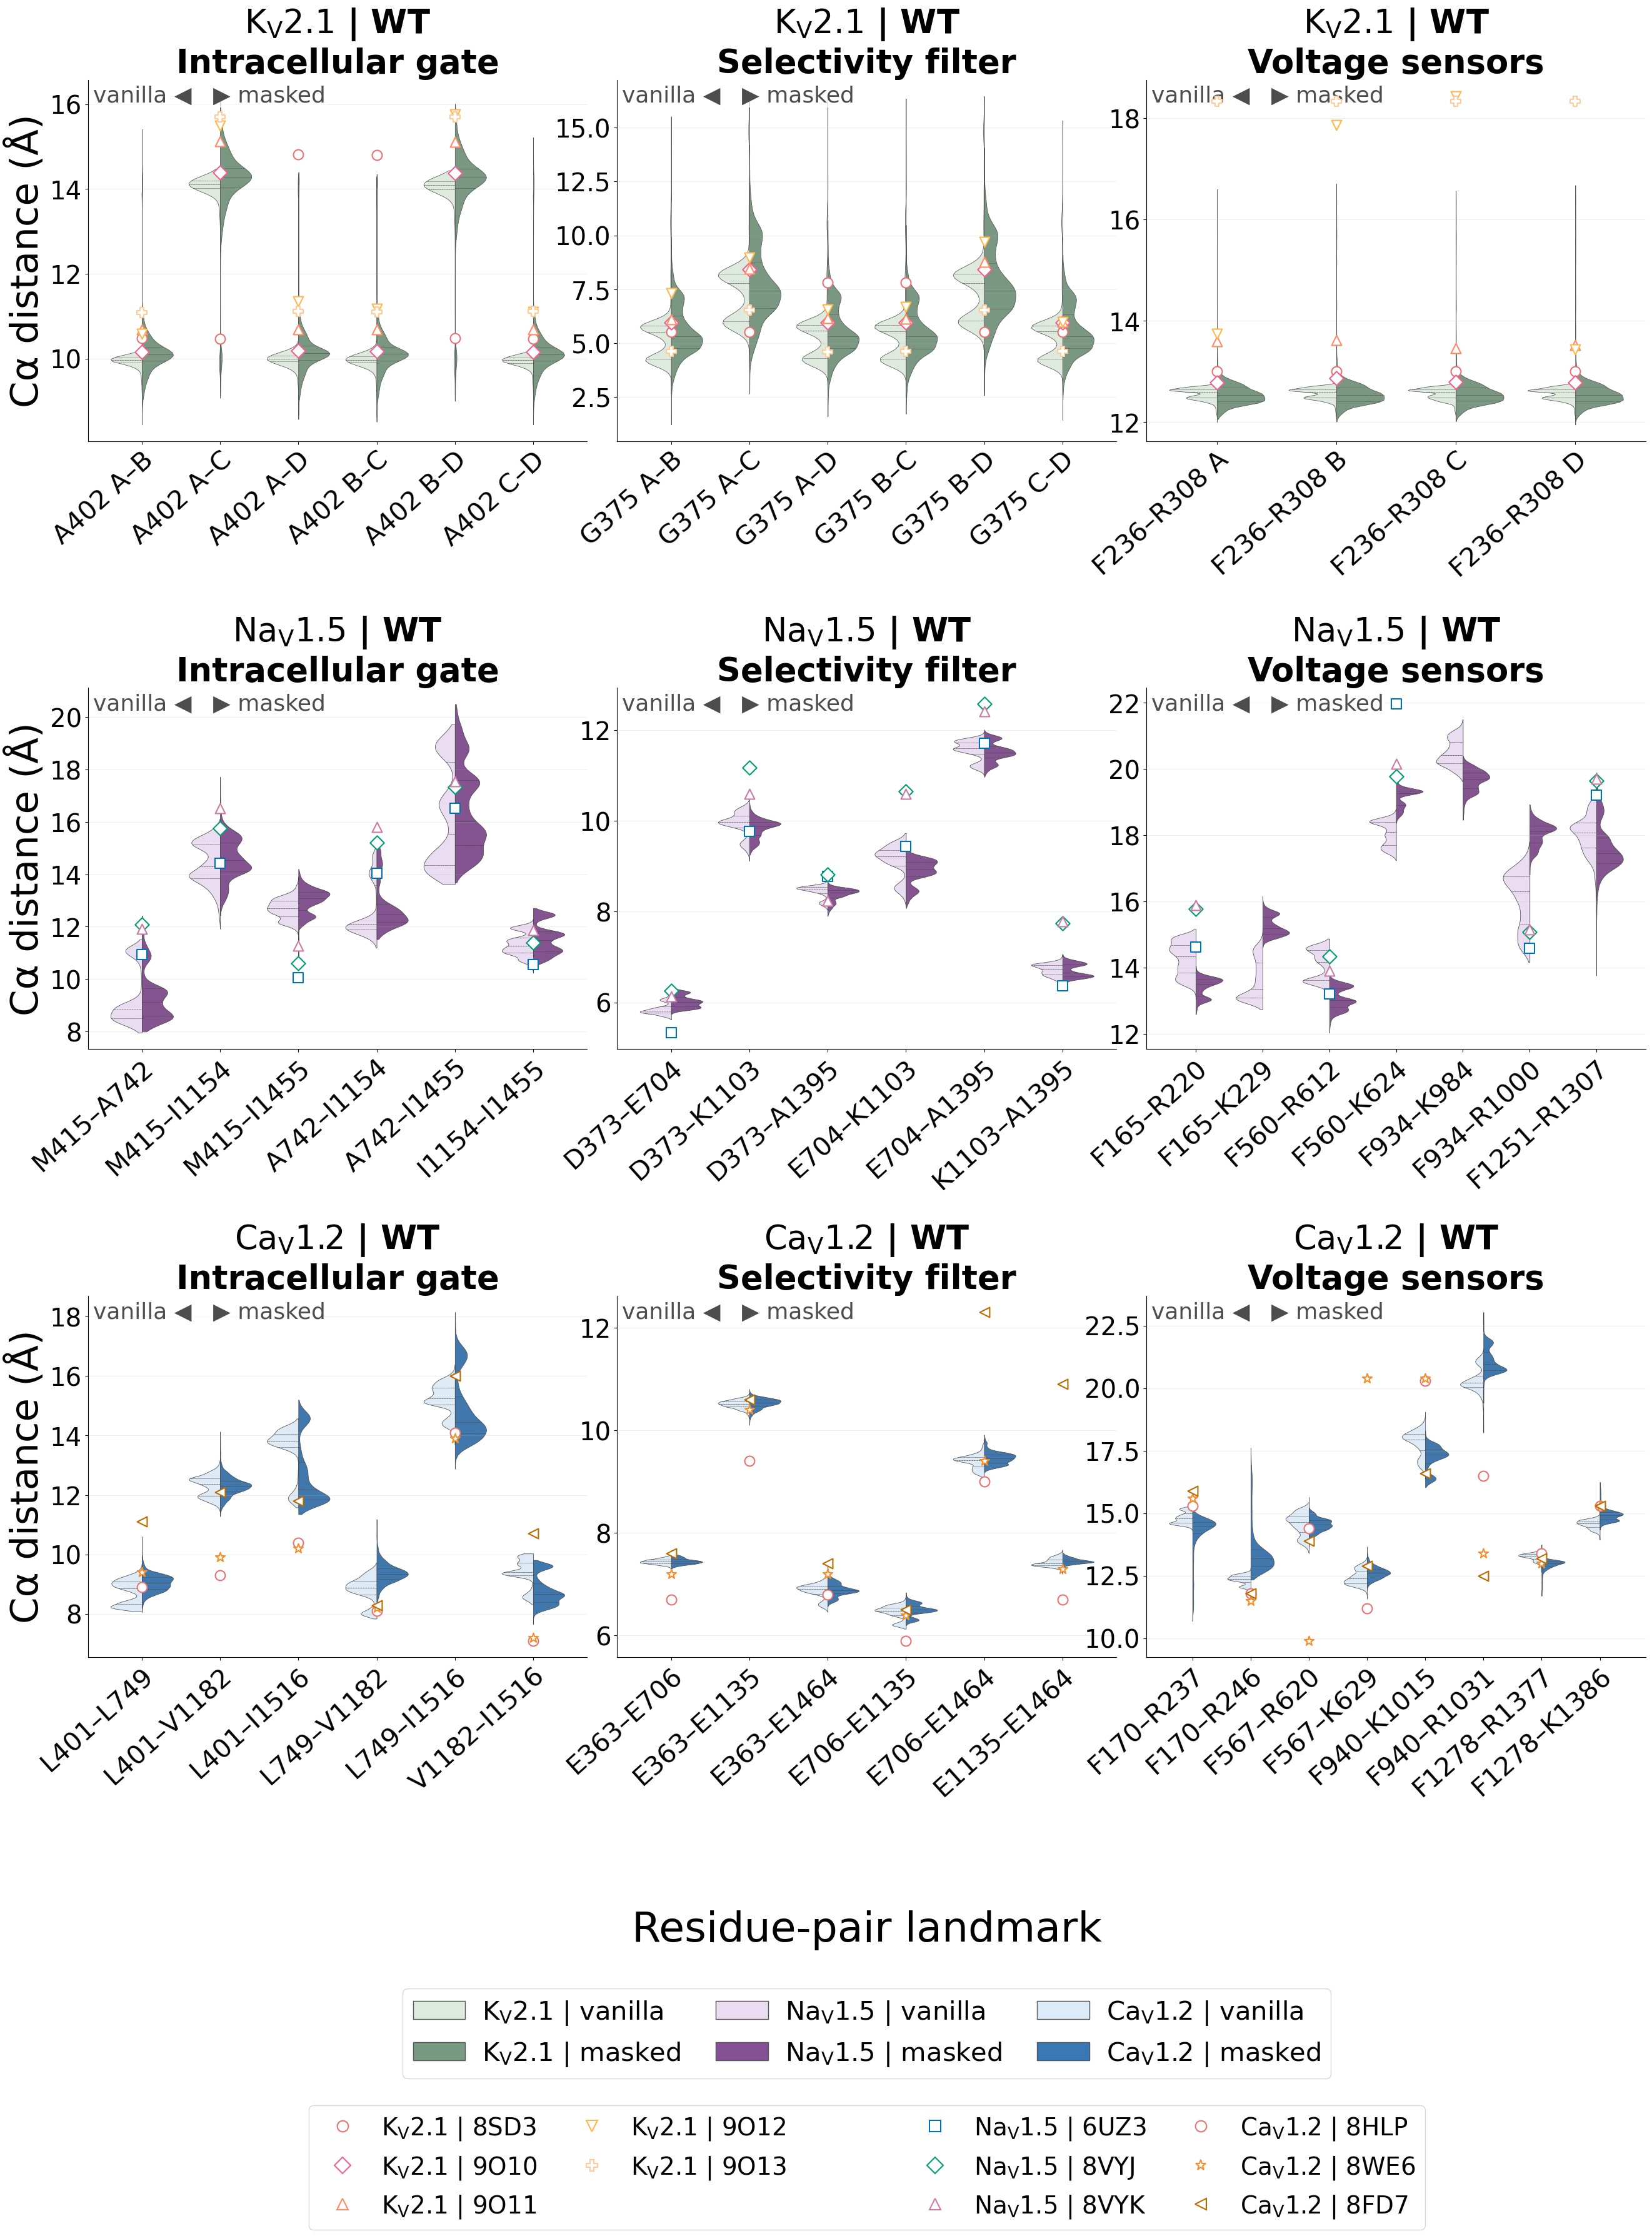

In [26]:
main_figure = make_grid(
    repo_root, configs, data,
    regions=('intracellular_gate', 'selectivity_filter', 'vsds'),
    output_path=figures / 'cross_channel_main_gate_filter_vsd.png',
)
display(main_figure)
plt.close(main_figure)

## Equal-size panel exports

Every channel–region panel below is exported at the same physical dimensions and resolution. These files can be placed directly into a manuscript table or rearranged without rescaling one channel relative to another.

In [27]:
panel_paths = make_individual_panels(repo_root, configs, data, figures / 'individual_panels')
print(f'Exported {len(panel_paths)} equal-size panels')
for path in panel_paths:
    print(path.relative_to(repo_root))

Exported 9 equal-size panels
docs/figures/cross_channel_distance_sampling/individual_panels/kv21_wt_selectivity_filter.png
docs/figures/cross_channel_distance_sampling/individual_panels/kv21_wt_vsds.png
docs/figures/cross_channel_distance_sampling/individual_panels/kv21_wt_intracellular_gate.png
docs/figures/cross_channel_distance_sampling/individual_panels/nav15_wt_selectivity_filter.png
docs/figures/cross_channel_distance_sampling/individual_panels/nav15_wt_vsds.png
docs/figures/cross_channel_distance_sampling/individual_panels/nav15_wt_intracellular_gate.png
docs/figures/cross_channel_distance_sampling/individual_panels/cav12_wt_selectivity_filter.png
docs/figures/cross_channel_distance_sampling/individual_panels/cav12_wt_vsds.png
docs/figures/cross_channel_distance_sampling/individual_panels/cav12_wt_intracellular_gate.png
